Импорты, seed и устройство

In [37]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, TensorDataset, random_split

import matplotlib.pyplot as plt
import pandas as pd

RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(torch.__version__)

BATCH_SIZE = 256 if device.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2

Device: cpu
2.10.0+cpu


базовый transform для CNN

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


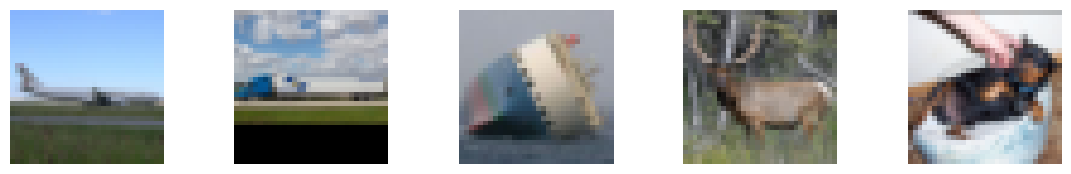

In [54]:
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)
transform_CNN = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

train_CNN = torchvision.datasets.STL10(
    root="./data", split='train', download=True, transform=transform_CNN
)
test_CNN = torchvision.datasets.STL10(
    root="./data", split='test', download=True, transform=transform_CNN
)

val_ratio = 0.2
val_size = int(len(train_CNN) * val_ratio)
train_size = len(train_CNN) - val_size

gen = torch.Generator().manual_seed(42)
train_CNN, val_CNN = random_split(train_CNN, [train_size, val_size], generator=gen)

train_loader_CNN = DataLoader(
    train_CNN, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader_CNN = DataLoader(
    val_CNN, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader_CNN = DataLoader(
    test_CNN, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader_CNN))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
x = x_batch[:5].cpu()
y = y_batch[:5].cpu()


def denorm(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

plt.figure(figsize=(14, 2))
for i in range(5):
  plt.subplot(1, 5, i + 1)
  img = denorm(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
  plt.imshow(img)
  plt.axis("off")
plt.show()


transform с аугментациями

In [ ]:
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)
transform_augmentation_train = transforms.Compose([
    transforms.Resize(32),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

transform_augmentation_test = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

train_augmentation = torchvision.datasets.STL10(
    root="./data", split='train', download=True, transform=transform_augmentation_train
)
test_augmentation = torchvision.datasets.STL10(
    root="./data", split='test', download=True, transform=transform_augmentation_test
)

val_ratio = 0.2
val_size = int(len(train_augmentation) * val_ratio)
train_size = len(train_augmentation) - val_size

gen = torch.Generator().manual_seed(42)
train_augmentation, val_augmentation = random_split(train_augmentation, [train_size, val_size], generator=gen)

train_loader_augmentation = DataLoader(
    train_augmentation, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader_augmentation = DataLoader(
    val_augmentation, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader_augmentation = DataLoader(
    test_augmentation, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader_augmentation))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


preprocessing для ResNet с pretrained weights

In [ ]:
IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
transform_preprocessing_train = transforms.Compose([
    transforms.Resize(32),
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_preprocessing_test = transforms.Compose([
    transforms.Resize(32),
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_preprocessing = torchvision.datasets.STL10(
    root="./data", split='train', download=True, transform=transform_preprocessing_train
)
test_preprocessing = torchvision.datasets.STL10(
    root="./data", split='test', download=True, transform=transform_preprocessing_test
)

val_ratio = 0.2
val_size = int(len(train_preprocessing) * val_ratio)
train_size = len(train_preprocessing) - val_size

gen = torch.Generator().manual_seed(42)
train_preprocessing, val_preprocessing = random_split(train_preprocessing, [train_size, val_size], generator=gen)

train_loader_preprocessing = DataLoader(
    train_preprocessing, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader_preprocessing = DataLoader(
    val_preprocessing, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader_preprocessing = DataLoader(
    test_preprocessing, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader_preprocessing))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 224, 224]) torch.float32
y_batch: torch.Size([64]) torch.int64


выбранный датасет для части B

In [ ]:
dataset = torchvision.datasets.VOCDetection(
    root='./data',
    year='2012',
    image_set='train',
    download=True,
    transform=transforms.ToTensor()
)

100.0%


In [ ]:
class VOCDetectionWrapper(torch.utils.data.Dataset):
    def __init__(self, root, image_set='train', year='2012', download=True):
        self.dataset = torchvision.datasets.VOCDetection(
            root=root,
            year=year,
            image_set=image_set,
            download=download,
            transform=transforms.ToTensor()
        )

        self.class_map = {
            'aeroplane': 1, 'bicycle': 2, 'bird': 3, 'boat': 4,
            'bottle': 5, 'bus': 6, 'car': 7, 'cat': 8, 'chair': 9,
            'cow': 10, 'diningtable': 11, 'dog': 12, 'horse': 13,
            'motorbike': 14, 'person': 15, 'pottedplant': 16,
            'sheep': 17, 'sofa': 18, 'train': 19, 'tvmonitor': 20
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, target = self.dataset[idx]

        boxes = []
        labels = []

        for obj in target['annotation']['object']:
            bbox = obj['bndbox']
            xmin = float(bbox['xmin'])
            ymin = float(bbox['ymin'])
            xmax = float(bbox['xmax'])
            ymax = float(bbox['ymax'])

            class_name = obj['name']
            if class_name in self.class_map:
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(self.class_map[class_name])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        image_id = torch.tensor([idx], dtype=torch.int64)
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target_formatted = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        return img, target_formatted

def collate_fn(batch):
    return tuple(zip(*batch))

dataset_train = VOCDetectionWrapper(root='./data', year='2012', image_set='train')
dataset_val = VOCDetectionWrapper(root='./data', year='2012', image_set='val')
len(dataset_train), dataset_train[0][0].shape, dataset_train[0][1].keys()
len(dataset_val)

5823

In [ ]:
train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset_val, batch_size=8, shuffle=False, num_workers=0)

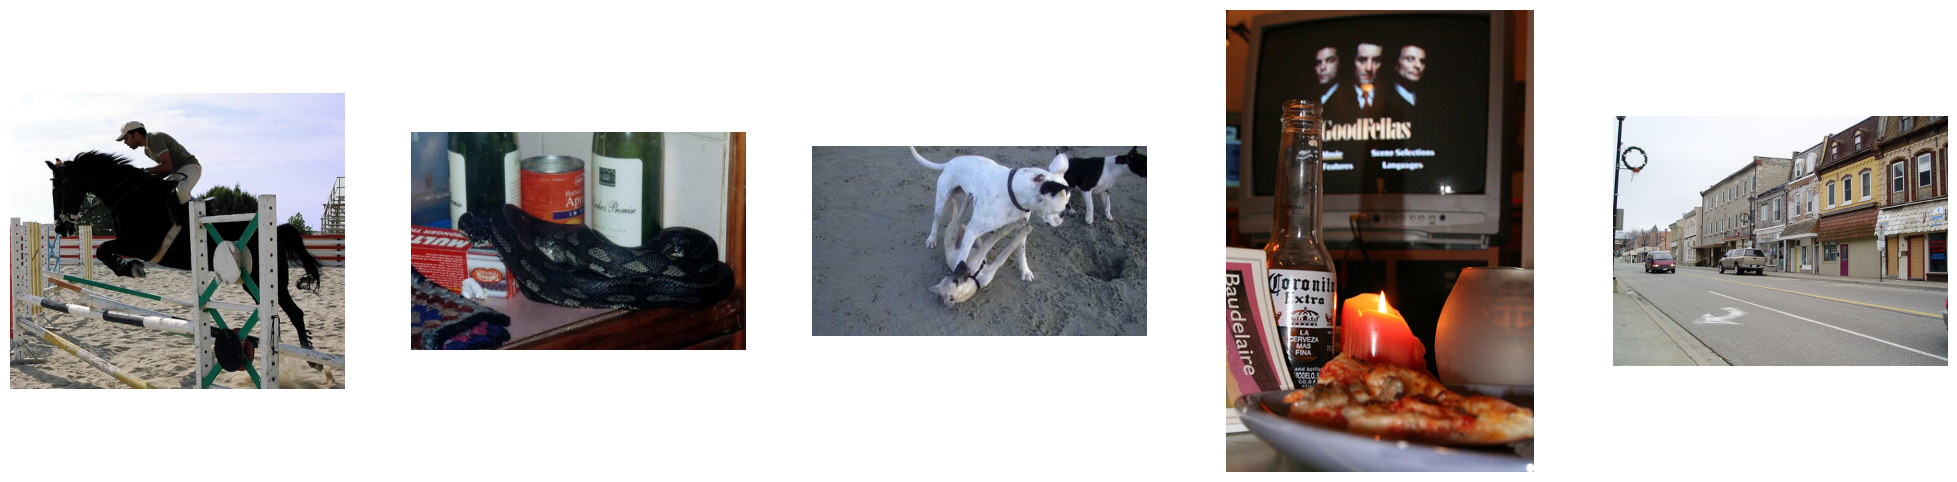

In [ ]:
def show_im(dataset, n=5):
    fig, axes = plt.subplots(1, 5, figsize=(25, 6))
    for i in range(n):
        img, species = dataset[i]
        img_np = img.permute(1,2,0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)
        axes[i].imshow(img_np)
        axes[i].axis('off')
    plt.show()

show_im(dataset_train, n=5)


In [ ]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_resnet18(num_classes=10, weights=weights).to(device)
print(model)


weights: ResNet18_Weights.IMAGENET1K_V1
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\chise/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


In [ ]:
def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

    return history

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(10).to(device)
print(cnn)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
runs = pd.DataFrame(columns=['experiment_id','task', 'dataset','seed','model_summary',
                             'optimizer','lr',
                             'epochs_trained','best_val_accuracy','test_accuracy', 'precision',
                             'recall', 'mean_iou', 'notes'])

C1

epoch 01/10 | train loss=1.9059, acc=0.2790 | val loss=1.6943, acc=0.3277
epoch 02/10 | train loss=1.5758, acc=0.4120 | val loss=1.4973, acc=0.4338
epoch 03/10 | train loss=1.4086, acc=0.4643 | val loss=1.4834, acc=0.4611
epoch 04/10 | train loss=1.2767, acc=0.5243 | val loss=1.3968, acc=0.4605
epoch 05/10 | train loss=1.1359, acc=0.5719 | val loss=1.3450, acc=0.5002
epoch 06/10 | train loss=1.0179, acc=0.6173 | val loss=1.3773, acc=0.5078
epoch 07/10 | train loss=0.8787, acc=0.6843 | val loss=1.3794, acc=0.5260
epoch 08/10 | train loss=0.7837, acc=0.7138 | val loss=1.4344, acc=0.5293
epoch 09/10 | train loss=0.6378, acc=0.7775 | val loss=1.5135, acc=0.5246
epoch 10/10 | train loss=0.5206, acc=0.8147 | val loss=1.4915, acc=0.5369


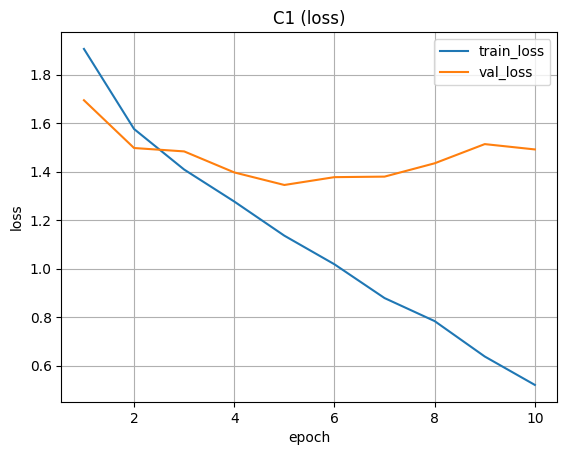

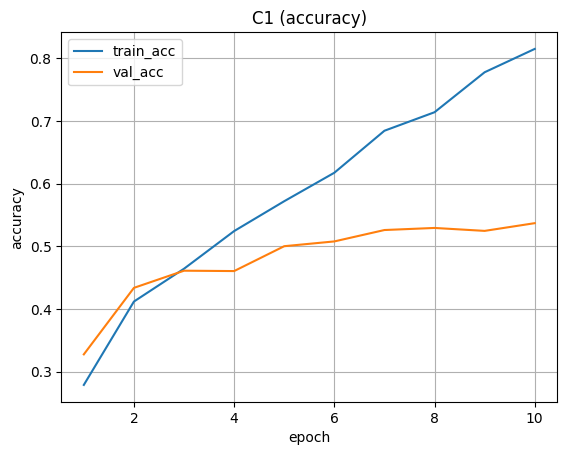

In [ ]:
set_seed()

C1 = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(C1.parameters(), lr=1e-3, weight_decay=0.0)

history_C1 = fit(
    C1, train_loader_CNN, val_loader_CNN,
    optimizer, criterion, device,
    epochs=10
)

plot_history(history_C1, title="C1")
best_val_C1 = max(history_C1['val_acc'])
C1_df = {'experiment_id': 'C1',
           'task': 'classification',
           'dataset': 'STL10',
           'seed': 42,
           'model_summary': 'simple-cnn-base',
           'optimizer': 'Adam',
           'lr': 1e-3,
           'epochs_trained': 10,
           'best_val_accuracy': max(history_C1['val_acc']),
           'test_accuracy': None,
           'precision': None,
           'recall': None,
           'mean_iou': None,
           'notes': None
           }
runs = pd.concat([runs, pd.DataFrame([C1_df])], ignore_index=True)

C2

epoch 01/10 | train loss=1.9079, acc=0.2780 | val loss=1.6992, acc=0.3297
epoch 02/10 | train loss=1.5918, acc=0.4005 | val loss=1.4795, acc=0.4199
epoch 03/10 | train loss=1.4358, acc=0.4573 | val loss=1.4281, acc=0.4514
epoch 04/10 | train loss=1.2960, acc=0.5112 | val loss=1.3592, acc=0.4898
epoch 05/10 | train loss=1.2252, acc=0.5412 | val loss=1.4543, acc=0.4713
epoch 06/10 | train loss=1.1283, acc=0.5848 | val loss=1.2746, acc=0.5117
epoch 07/10 | train loss=1.0547, acc=0.6114 | val loss=1.2774, acc=0.5340
epoch 08/10 | train loss=0.9520, acc=0.6493 | val loss=1.2494, acc=0.5600
epoch 09/10 | train loss=0.8842, acc=0.6773 | val loss=1.4094, acc=0.5303
epoch 10/10 | train loss=0.8012, acc=0.7076 | val loss=1.2547, acc=0.5646


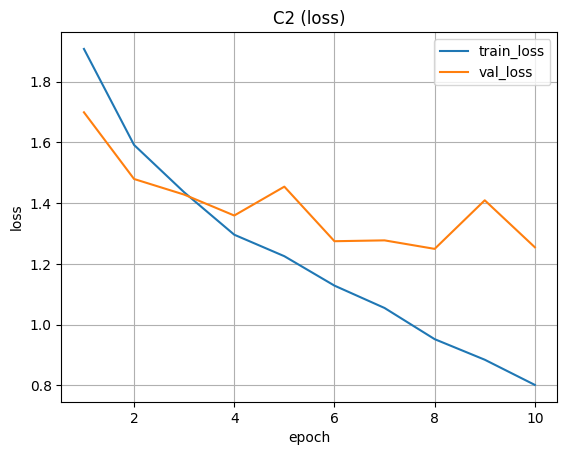

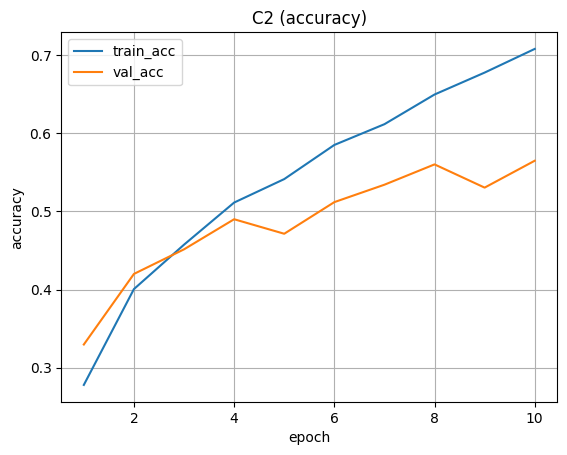

In [ ]:
set_seed()

C2 = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(C2.parameters(), lr=1e-3, weight_decay=0.0)

history_C2 = fit(
    C2, train_loader_augmentation, val_loader_augmentation,
    optimizer, criterion, device,
    epochs=10
)

plot_history(history_C2, title="C2")
best_val_C2 = max(history_C2['val_acc'])
C2_df = {'experiment_id': 'C2',
           'task': 'classification',
           'dataset': 'STL10',
           'seed': 42,
           'model_summary': 'simple-cnn-augmentation',
           'optimizer': 'Adam',
           'lr': 1e-3,
           'epochs_trained': 10,
           'best_val_accuracy': max(history_C2['val_acc']),
           'test_accuracy': None,
           'precision': None,
           'recall': None,
           'mean_iou': None,
           'notes': None
           }
runs = pd.concat([runs, pd.DataFrame([C2_df])], ignore_index=True)

C3

In [ ]:
def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Phase 1: head-only training
epoch 01/10 | train loss=1.7656, acc=0.3996 | val loss=1.2922, acc=0.5953
epoch 02/10 | train loss=1.1593, acc=0.6411 | val loss=1.0218, acc=0.6773
epoch 03/10 | train loss=0.9492, acc=0.7160 | val loss=0.8943, acc=0.7100
epoch 04/10 | train loss=0.8788, acc=0.7163 | val loss=0.8380, acc=0.7344
epoch 05/10 | train loss=0.8257, acc=0.7205 | val loss=0.8338, acc=0.7105
epoch 06/10 | train loss=0.7851, acc=0.7366 | val loss=0.8007, acc=0.7207
epoch 07/10 | train loss=0.7607, acc=0.7460 | val loss=0.7951, acc=0.7188
epoch 08/10 | train loss=0.7386, acc=0.7458 | val loss=0.8078, acc=0.7170
epoch 09/10 | train loss=0.7242, acc=0.7525 | val loss=0.7965, acc=0.7211
epoch 10/10 | train loss=0.7161, acc=0.7560 | val loss=0.7743, acc=0.7420


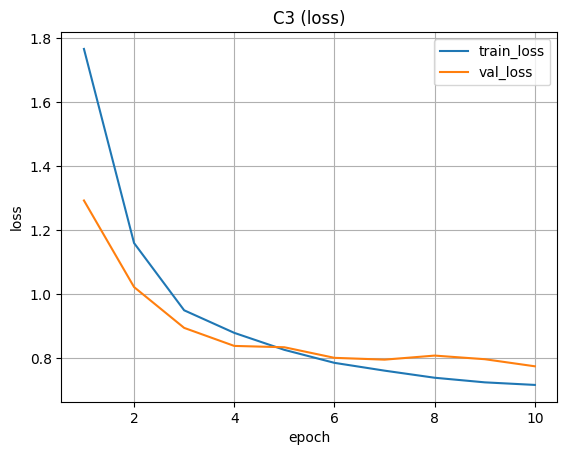

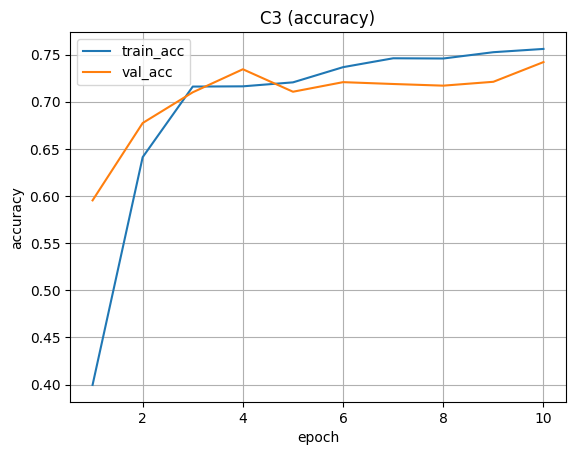

In [ ]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(device)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("Phase 1: head-only training")
history_C3 = fit(model_head, train_loader_preprocessing, val_loader_preprocessing, optimizer_head, criterion, device, epochs=10, verbose=True)
plot_history(history_C3, title="C3")
best_val_C3 = max(history_C3['val_acc'])

C3_df = {'experiment_id': 'C3',
           'task': 'classification',
           'dataset': 'STL10',
           'seed': 42,
           'model_summary': 'resnet18-head-only',
           'optimizer': 'Adam',
           'lr': 1e-3,
           'epochs_trained': 10,
           'best_val_accuracy': max(history_C3['val_acc']),
           'test_accuracy': None,
           'precision': None,
           'recall': None,
           'mean_iou': None,
           'notes': None
           }
runs = pd.concat([runs, pd.DataFrame([C3_df])], ignore_index=True)

C4

Phase 2: fine-tuning layer4 + fc
epoch 01/10 | train loss=0.1642, acc=0.9472 | val loss=0.6822, acc=0.7957
epoch 02/10 | train loss=0.1196, acc=0.9576 | val loss=0.7205, acc=0.7893
epoch 03/10 | train loss=0.1159, acc=0.9635 | val loss=0.6875, acc=0.8084
epoch 04/10 | train loss=0.0904, acc=0.9685 | val loss=0.7176, acc=0.8088
epoch 05/10 | train loss=0.0815, acc=0.9727 | val loss=0.6845, acc=0.8127
epoch 06/10 | train loss=0.0578, acc=0.9821 | val loss=0.7429, acc=0.8111
epoch 07/10 | train loss=0.0718, acc=0.9762 | val loss=0.7959, acc=0.8025
epoch 08/10 | train loss=0.0649, acc=0.9769 | val loss=0.8025, acc=0.8008
epoch 09/10 | train loss=0.0455, acc=0.9864 | val loss=0.7315, acc=0.8254
epoch 10/10 | train loss=0.0502, acc=0.9841 | val loss=0.7337, acc=0.8242


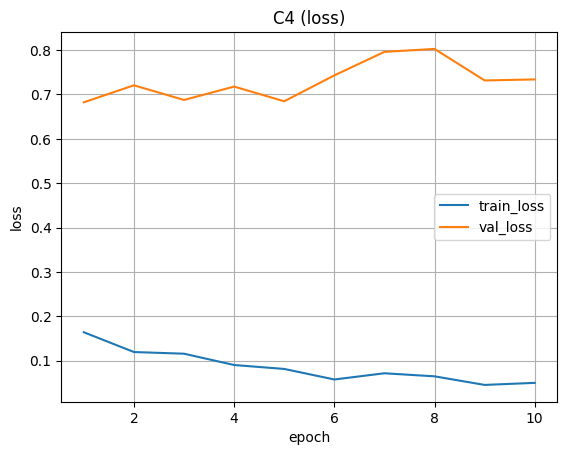

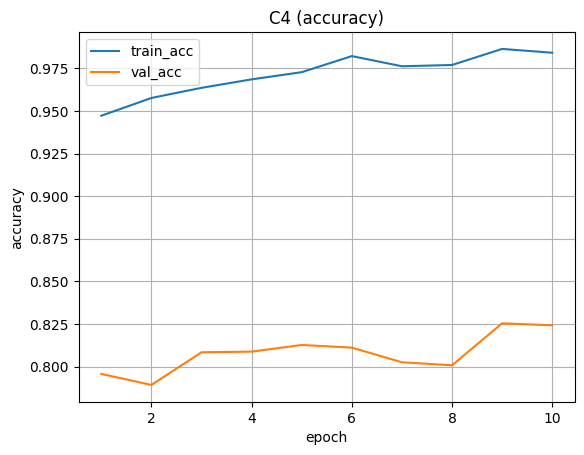

In [ ]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("Phase 2: fine-tuning layer4 + fc")
history_C4 = fit(model_head, train_loader_preprocessing, val_loader_preprocessing, optimizer_ft, criterion, device, epochs=10, verbose=True)
plot_history(history_C4, title="C4")
best_val_C4 = max(history_C4['val_acc'])
test_acc_C4, test_loss_C4 = evaluate(model_head, test_loader_preprocessing, criterion, device)
C4_df = {'experiment_id': 'C4',
           'task': 'classification',
           'dataset': 'STL10',
           'seed': 42,
           'model_summary': 'resnet18-finetune',
           'optimizer': 'Adam',
           'lr': 1e-3,
           'epochs_trained': 10,
           'best_val_accuracy': max(history_C4['val_acc']),
           'test_accuracy': test_acc_C4,
           'precision': None,
           'recall': None,
           'mean_iou': None,
           'notes': None
           }
runs = pd.concat([runs, pd.DataFrame([C4_df])], ignore_index=True)


In [ ]:
runs

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple-cnn-base,Adam,0.001,10,0.536914,None,None,None,None,None
1,C2,classification,STL10,42,simple-cnn-augmentation,Adam,0.001,10,0.564648,None,None,None,None,None
2,C3,classification,STL10,42,resnet18-head-only,Adam,0.001,10,0.741992,None,None,None,None,None
3,C4,classification,STL10,42,resnet18-finetune,Adam,0.001,10,0.825391,0.764056,None,None,None,None


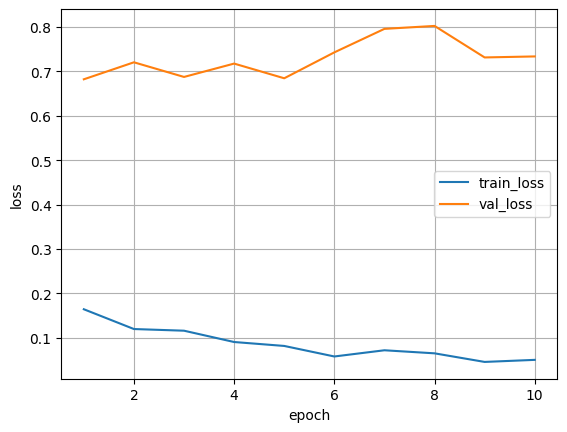

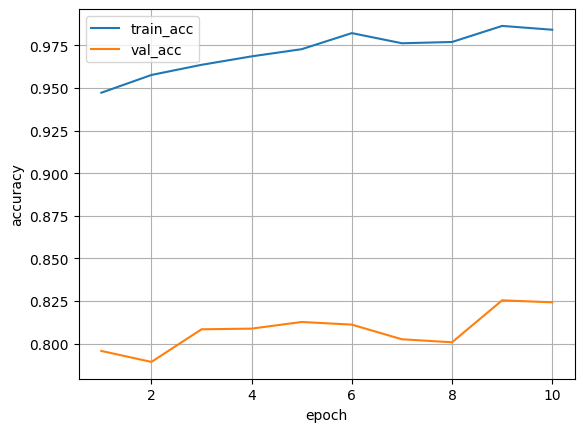

In [ ]:

epochs = np.arange(1, len(history_C4["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history_C4["train_loss"], label="train_loss")
plt.plot(epochs, history_C4["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history_C4["train_acc"], label="train_acc")
plt.plot(epochs, history_C4["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

In [49]:
import json
best_config = runs.iloc[3].to_dict()
best_config.pop('experiment_id')
best_config['transforms'] = 'Resize(32), Resize(IMG_SIZE + 32), RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)), RandomHorizontalFlip(p=0.5), ToTensor(), Normalize(IMAGENET_MEAN, IMAGENET_STD)'
best_config['network'] = 'resnet18'
print(best_config)
with open('artifacts/best_classifier_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=4)

{'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': 'resnet18-finetune', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': 10, 'best_val_accuracy': 0.8253906257450581, 'test_accuracy': 0.7640559611320495, 'precision': None, 'recall': None, 'mean_iou': None, 'notes': None, 'transforms': 'Resize(32), Resize(IMG_SIZE + 32), RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)), RandomHorizontalFlip(p=0.5), ToTensor(), Normalize(IMAGENET_MEAN, IMAGENET_STD)', 'network': 'resnet18'}


In [51]:
torch.save(model_head.state_dict(), 'artifacts/best_classifier.pt')

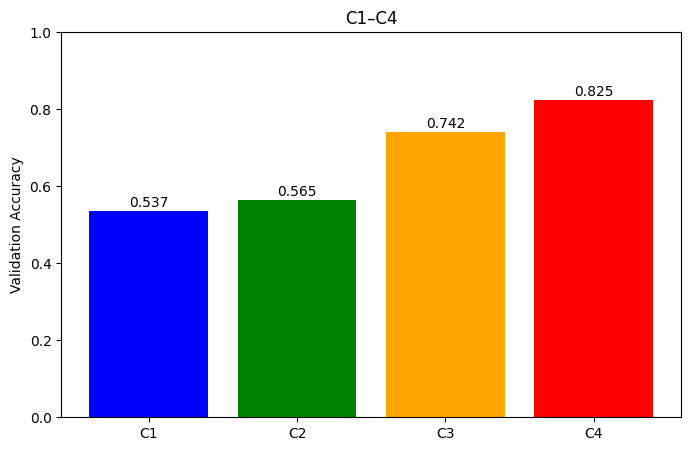

In [ ]:
exp_names = ['C1', 'C2', 'C3', 'C4']
val_accs = [best_val_C1, best_val_C2, best_val_C3,best_val_C4]
plt.figure(figsize=(8,5))
bars = plt.bar(exp_names, val_accs, color=['blue','green','orange','red'])
plt.ylim(0,1)
plt.ylabel('Validation Accuracy')
plt.title('C1–C4')
for bar, acc in zip(bars, val_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center')
plt.savefig('artifacts/figures/classification_compare.png', dpi=150)
plt.show()


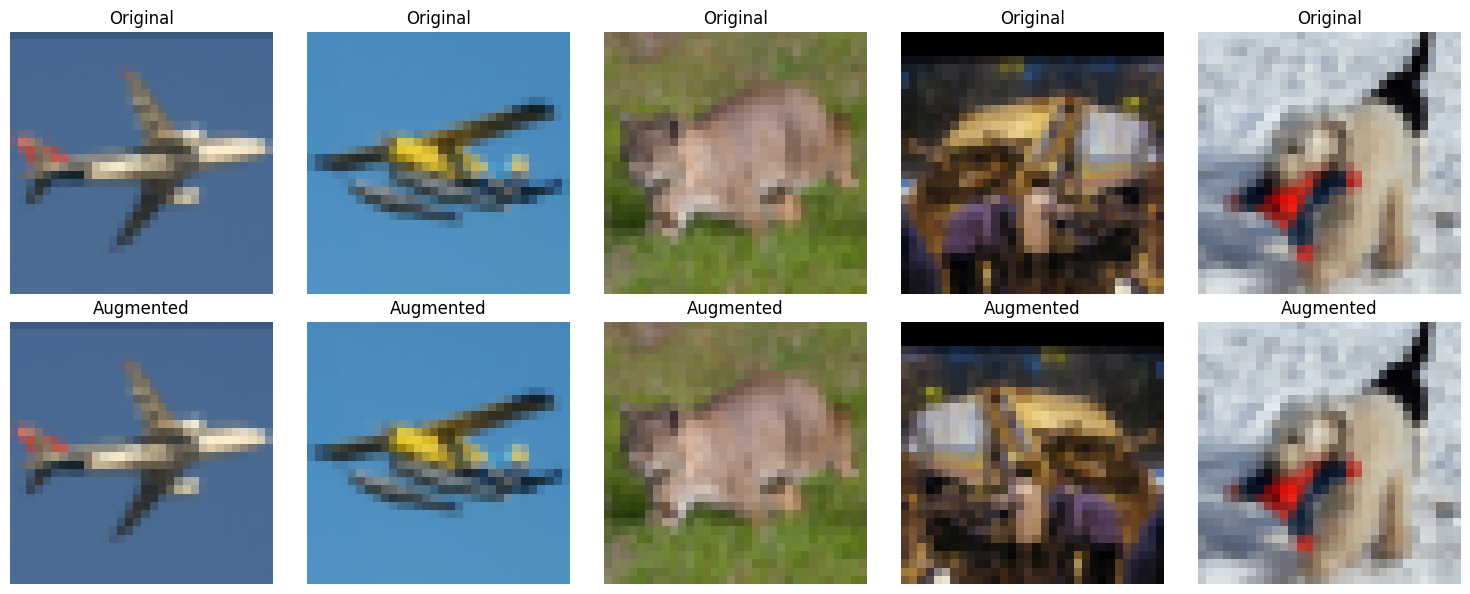

In [ ]:
def show_augmentations(dataset_orig, dataset_aug, n=5):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        img_orig, _ = dataset_orig[i]
        img_aug, _ = dataset_aug[i]
        axes[0,i].imshow(denorm(img_orig).permute(1,2,0).clamp(0,1))
        axes[0,i].set_title('Original')
        axes[0,i].axis('off')
        axes[1,i].imshow(denorm(img_aug).permute(1,2,0).clamp(0,1))
        axes[1,i].set_title('Augmented')
        axes[1,i].axis('off')
    plt.tight_layout()
    plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150)
    plt.show()

show_augmentations(train_CNN, train_augmentation, n=5)

Часть B

In [ ]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 4                 # сколько примеров визуализируем
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_resnet50_fpn_v2"

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=4, iou_thr=0.5, model_name='fasterrcnn_resnet50_fpn_v2')

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights).to(device)

categories = weights.meta.get("categories", None)
person_label = None
if categories and "person" in categories:
    person_label = categories.index("person")


model.eval()

print("model:", cfg.model_name)
print("person_label:", person_label)

model: fasterrcnn_resnet50_fpn_v2
person_label: 1


In [39]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(device)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, person_label: Optional[int]) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if person_label is not None and "labels" in pred:
        keep = keep & (pred["labels"] == int(person_label))
    return {k: v[keep] for k, v in pred.items()}

def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union


def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou





V1

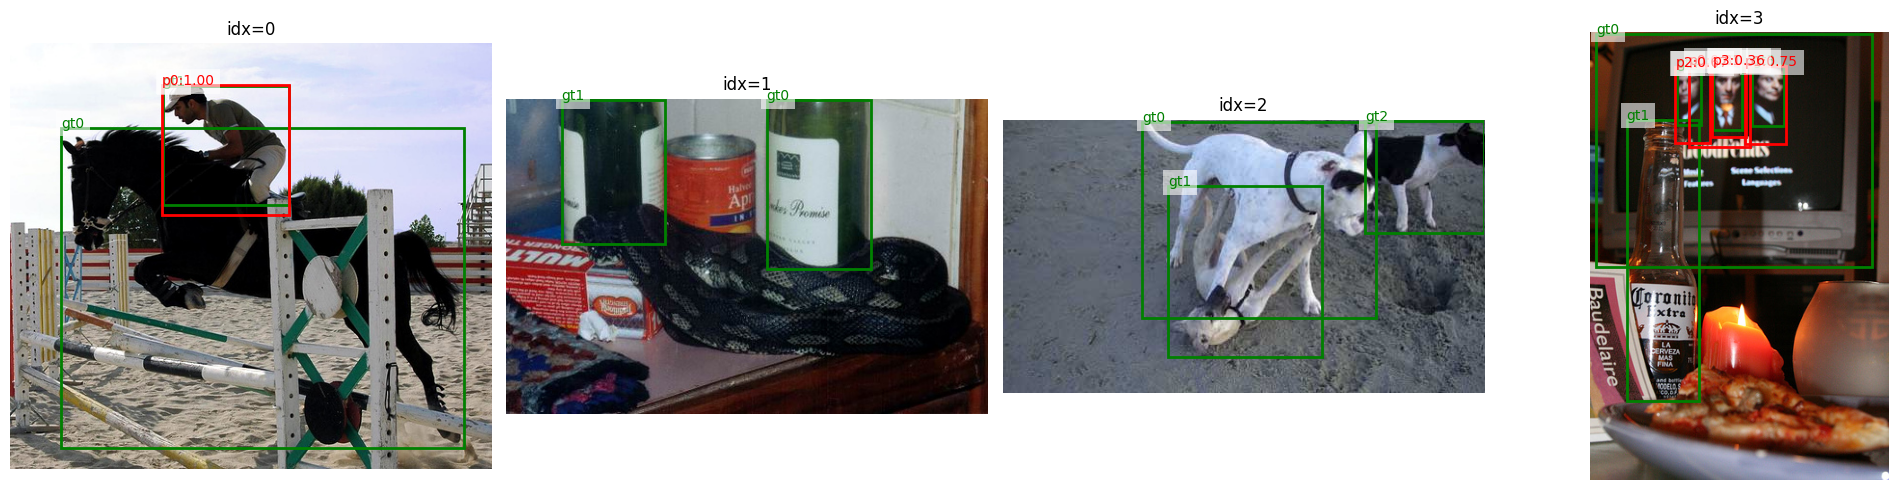

In [41]:

# Покажем несколько примеров
n = min(4, len(dataset_train))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset_train[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, 0.3, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.show()

In [42]:
def evaluate_subset(indices: List[int], score_threshold) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset_train[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, score_threshold, person_label)

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "mean_IoU_matched": mean_iou,
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset_train))))
else:
    eval_indices = list(range(len(dataset_train)))

metrics_v1 = evaluate_subset(eval_indices, 0.3)
metrics_v1

{'TP': 13.0,
 'FP': 10.0,
 'FN': 38.0,
 'precision@IoU': 0.5652173912797731,
 'recall@IoU': 0.25490196077931565,
 'mean_IoU_matched': 0.8134423863320123}

In [ ]:
V1_df = {'experiment_id': 'V1',
           'task': 'detection',
           'dataset': 'VOCDetection',
           'seed': 42,
           'model_summary': 'fasterrcnn_resnet50_fpn_v2',
           'optimizer': None,
           'lr': None,
           'epochs_trained': None,
           'best_val_accuracy': None,
           'test_accuracy': None,
           'precision': metrics_v1['precision@IoU'],
           'recall': metrics_v1['recall@IoU'],
           'mean_iou': metrics_v1['mean_IoU_matched'],
           'notes': None
           }
runs = pd.concat([runs, pd.DataFrame([V1_df])], ignore_index=True)

V2

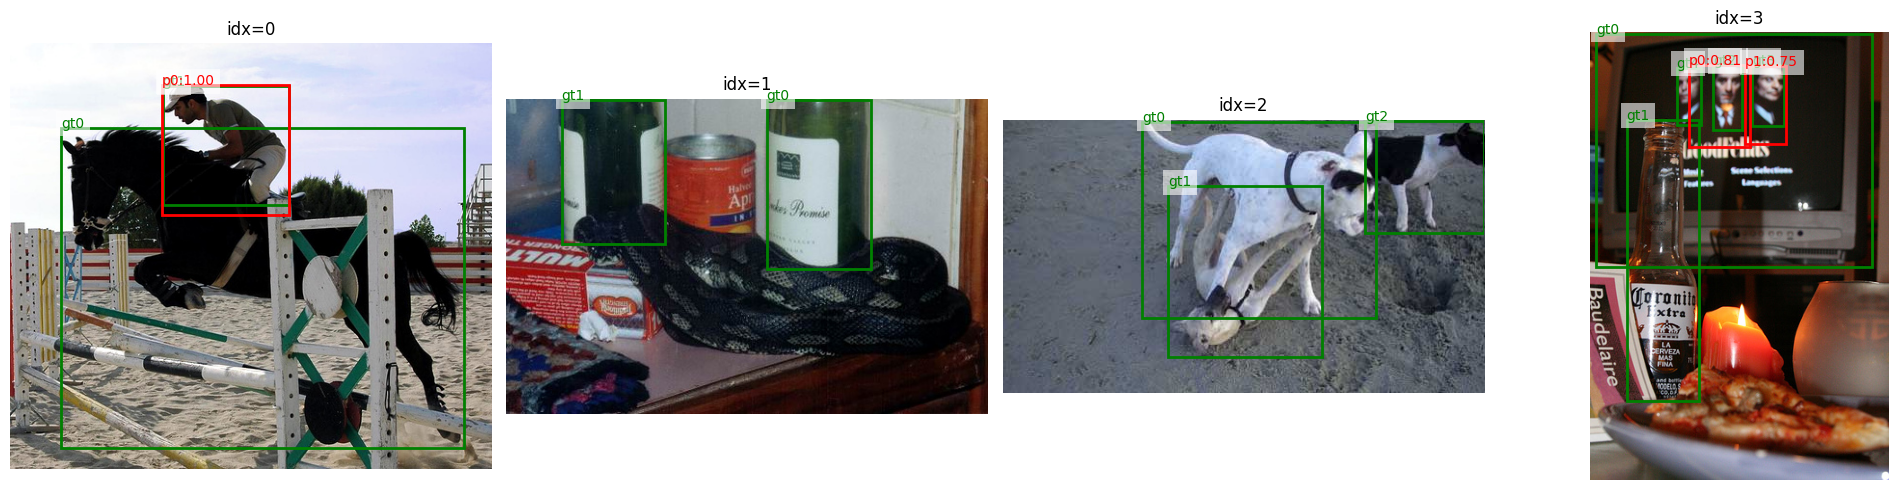

In [46]:
# Покажем несколько примеров
n = min(4, len(dataset_train))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset_train[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, 0.7, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.savefig('artifacts/figures/detection_examples.png')
plt.show()


In [45]:
metrics_v2 = evaluate_subset(eval_indices, 0.7)
metrics_v2

{'TP': 11.0,
 'FP': 3.0,
 'FN': 40.0,
 'precision@IoU': 0.7857142856581633,
 'recall@IoU': 0.2156862745055748,
 'mean_IoU_matched': 0.8053291848727635}

In [47]:
V2_df = {'experiment_id': 'V2',
           'task': 'detection',
           'dataset': 'VOCDetection',
           'seed': 42,
           'model_summary': 'fasterrcnn_resnet50_fpn_v2',
           'optimizer': None,
           'lr': None,
           'epochs_trained': None,
           'best_val_accuracy': None,
           'test_accuracy': None,
           'precision': metrics_v2['precision@IoU'],
           'recall': metrics_v2['recall@IoU'],
           'mean_iou': metrics_v2['mean_IoU_matched'],
           'notes': None
           }
runs = pd.concat([runs, pd.DataFrame([V2_df])], ignore_index=True)

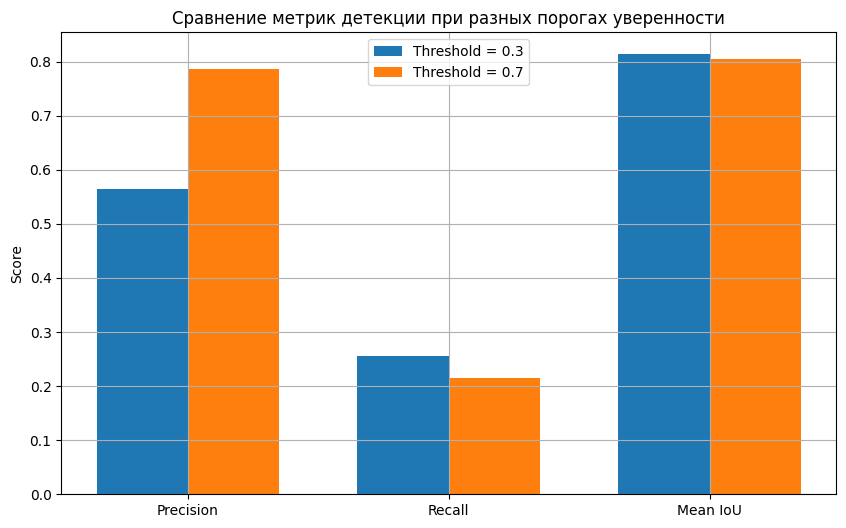

In [52]:
metric_keys = ['precision@IoU', 'recall@IoU', 'mean_IoU_matched']
metric_labels = ['Precision', 'Recall', 'Mean IoU']


v1_values = [metrics_v1[k] for k in metric_keys]
v2_values = [metrics_v2[k] for k in metric_keys]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, v1_values, width, label='Threshold = 0.3')
bars2 = ax.bar(x + width/2, v2_values, width, label='Threshold = 0.7')


ax.set_ylabel('Score')
ax.set_title('Сравнение метрик детекции при разных порогах уверенности')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.legend()
ax.grid()
plt.savefig('artifacts/figures/detection_metrics.png')
plt.show()

In [53]:
runs.to_csv("artifacts/runs.csv")